# Imports

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from google.colab import userdata
import json

# Loading API Key

In [12]:
from google.colab import userdata

OPENWEATHER_API_KEY = userdata.get("OPENWEATHER_API_KEY")

if OPENWEATHER_API_KEY:
    OPENWEATHER_API_KEY = OPENWEATHER_API_KEY.strip()

print("Key loaded:", OPENWEATHER_API_KEY is not None)
print("Key length:", len(OPENWEATHER_API_KEY))

Key loaded: True
Key length: 32


# User Inputs - Default Bangalore

In [13]:
LATITUDE = 12.9716
LONGITUDE = 77.5946
LOCATION_NAME = "Bangalore, India"

UNITS = "metric"
LANGUAGE = "en"

# Weather API Function

In [14]:
def fetch_current_weather(lat, lon, api_key, units="metric", lang="en"):
    url = "https://api.openweathermap.org/data/2.5/weather"

    params = {
        "lat": lat,
        "lon": lon,
        "appid": api_key,
        "units": units,
        "lang": lang
    }

    response = requests.get(url, params=params, timeout=20)

    if response.status_code != 200:
        raise Exception(f"Current Weather API Error {response.status_code}: {response.text}")

    return response.json()

In [15]:
def fetch_forecast_weather(lat, lon, api_key, units="metric", lang="en"):
    url = "https://api.openweathermap.org/data/2.5/forecast"

    params = {
        "lat": lat,
        "lon": lon,
        "appid": api_key,
        "units": units,
        "lang": lang
    }

    response = requests.get(url, params=params, timeout=20)

    if response.status_code != 200:
        raise Exception(f"Forecast API Error {response.status_code}: {response.text}")

    return response.json()

# Fetch Data

In [16]:
current_data = fetch_current_weather(
    lat=LATITUDE,
    lon=LONGITUDE,
    api_key=OPENWEATHER_API_KEY,
    units=UNITS,
    lang=LANGUAGE
)

forecast_data = fetch_forecast_weather(
    lat=LATITUDE,
    lon=LONGITUDE,
    api_key=OPENWEATHER_API_KEY,
    units=UNITS,
    lang=LANGUAGE
)

print("Current weather keys:", current_data.keys())
print("Forecast weather keys:", forecast_data.keys())

Current weather keys: dict_keys(['coord', 'weather', 'base', 'main', 'visibility', 'wind', 'clouds', 'dt', 'sys', 'timezone', 'id', 'name', 'cod'])
Forecast weather keys: dict_keys(['cod', 'message', 'cnt', 'list', 'city'])


# Raw API Responses

In [17]:
raw_weather_response = {
    "current_weather": current_data,
    "forecast_weather": forecast_data
}

with open("raw_weather_response.json", "w") as file:
    json.dump(raw_weather_response, file, indent=4)

print("Raw weather data saved successfully.")

Raw weather data saved successfully.


# Current Weather DataFrame

In [18]:
current_weather_summary = {
    "location": LOCATION_NAME,
    "timestamp": datetime.fromtimestamp(current_data["dt"]),
    "temperature_celsius": current_data["main"].get("temp"),
    "feels_like_celsius": current_data["main"].get("feels_like"),
    "humidity_percent": current_data["main"].get("humidity"),
    "pressure_hpa": current_data["main"].get("pressure"),
    "wind_speed_mps": current_data["wind"].get("speed"),
    "cloudiness_percent": current_data["clouds"].get("all"),
    "weather_main": current_data["weather"][0].get("main"),
    "weather_description": current_data["weather"][0].get("description")
}

current_weather_df = pd.DataFrame([current_weather_summary])
current_weather_df

,location,timestamp,temperature_celsius,feels_like_celsius,humidity_percent,pressure_hpa,wind_speed_mps,cloudiness_percent,weather_main,weather_description
0,"Bangalore, India",2026-06-01 21:37:37,23.19,23.71,82,1011,5.81,40,Clouds,scattered clouds


# Forecast DataFrame

In [19]:
forecast_records = []

for item in forecast_data["list"]:
    forecast_records.append({
        "datetime": datetime.fromtimestamp(item["dt"]),
        "temperature_celsius": item["main"].get("temp"),
        "feels_like_celsius": item["main"].get("feels_like"),
        "humidity_percent": item["main"].get("humidity"),
        "pressure_hpa": item["main"].get("pressure"),
        "wind_speed_mps": item["wind"].get("speed"),
        "cloudiness_percent": item["clouds"].get("all"),
        "pop_probability": item.get("pop", 0),
        "weather_main": item["weather"][0].get("main"),
        "weather_description": item["weather"][0].get("description")
    })

forecast_df = pd.DataFrame(forecast_records)
forecast_df.head()

,datetime,temperature_celsius,feels_like_celsius,humidity_percent,pressure_hpa,wind_speed_mps,cloudiness_percent,pop_probability,weather_main,weather_description
0,2026-06-02 00:00:00,23.00,23.44,80,1012,2.12,57,1.0,Rain,light rain
1,2026-06-02 03:00:00,22.79,23.16,78,1013,2.82,80,0.0,Clouds,broken clouds
2,2026-06-02 06:00:00,24.78,25.06,67,1013,2.50,99,0.0,Clouds,overcast clouds
3,2026-06-02 09:00:00,28.99,29.53,49,1009,2.43,75,0.0,Clouds,broken clouds
4,2026-06-02 12:00:00,29.65,30.00,46,1008,2.17,58,0.0,Clouds,broken clouds


# Daily Summary Dataframe

In [20]:
forecast_df["date"] = forecast_df["datetime"].dt.date

daily_summary_df = forecast_df.groupby("date").agg(
    temp_min_celsius=("temperature_celsius", "min"),
    temp_max_celsius=("temperature_celsius", "max"),
    temp_avg_celsius=("temperature_celsius", "mean"),
    humidity_avg_percent=("humidity_percent", "mean"),
    wind_speed_avg_mps=("wind_speed_mps", "mean"),
    rain_probability_max=("pop_probability", "max"),
    cloudiness_avg_percent=("cloudiness_percent", "mean")
).reset_index()

daily_summary_df

,date,temp_min_celsius,temp_max_celsius,temp_avg_celsius,humidity_avg_percent,wind_speed_avg_mps,rain_probability_max,cloudiness_avg_percent
0,2026-06-02,22.79,29.65,25.72500,64.000,2.74500,1.00,66.250
1,2026-06-03,21.69,30.16,25.56375,63.250,4.20250,1.00,79.875
2,2026-06-04,21.33,28.89,24.83750,65.750,5.05625,1.00,89.375
3,2026-06-05,20.79,30.26,24.89000,62.625,5.57250,0.20,59.375
4,2026-06-06,20.71,31.10,24.83875,65.750,5.64625,0.42,81.750


# Visualization

In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.collections import LineCollection

os.makedirs("weather_charts", exist_ok=True)

# 5 Day temp forecast

In [24]:
def apply_chart_style(ax, title, xlabel, ylabel):
    ax.set_title(title, fontsize=15, fontweight="bold", pad=15)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)

    ax.set_facecolor("#F8FAFC")
    ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.45)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(axis="x", rotation=45)

In [25]:
def format_time_axis(ax):
    locator = mdates.HourLocator(interval=12)
    formatter = mdates.DateFormatter("%d %b\n%I %p")

    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)

In [36]:
def plot_gradient_line(
    df,
    x_col,
    y_col,
    title,
    ylabel,
    save_path,
    cmap="coolwarm"
):
    x = mdates.date2num(df[x_col])
    y = df[y_col].values

    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    fig, ax = plt.subplots(figsize=(13, 5))
    fig.patch.set_facecolor("white")

    norm = plt.Normalize(y.min(), y.max())

    line_collection = LineCollection(
        segments,
        cmap=cmap,
        norm=norm,
        linewidth=3
    )

    line_collection.set_array(y)
    ax.add_collection(line_collection)

    ax.scatter(df[x_col], y, s=28, c=y, cmap=cmap, norm=norm, edgecolor="black", linewidth=0.4)

    ax.set_xlim(df[x_col].min(), df[x_col].max())
    ax.set_ylim(y.min() - 1, y.max() + 1)

    apply_chart_style(
        ax=ax,
        title=title,
        xlabel="Forecast Time",
        ylabel=ylabel
    )

    format_time_axis(ax)

    colorbar = fig.colorbar(line_collection, ax=ax, pad=0.02)
    colorbar.set_label(ylabel)

    max_idx = df[y_col].idxmax()
    min_idx = df[y_col].idxmin()

    ax.annotate(
        f"Max: {df.loc[max_idx, y_col]:.1f}",
        xy=(df.loc[max_idx, x_col], df.loc[max_idx, y_col]),
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

    ax.annotate(
        f"Min: {df.loc[min_idx, y_col]:.1f}",
        xy=(df.loc[min_idx, x_col], df.loc[min_idx, y_col]),
        xytext=(0, -20),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

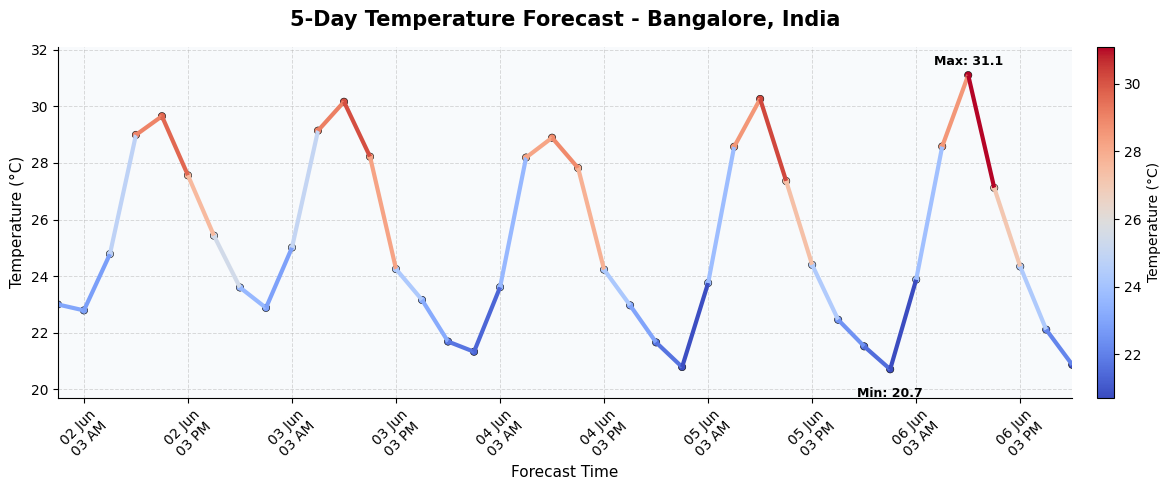

In [37]:
plot_gradient_line(
    df=forecast_df,
    x_col="datetime",
    y_col="temperature_celsius",
    title=f"5-Day Temperature Forecast - {LOCATION_NAME}",
    ylabel="Temperature (°C)",
    save_path="weather_charts/temperature_forecast.png",
    cmap="coolwarm"
)

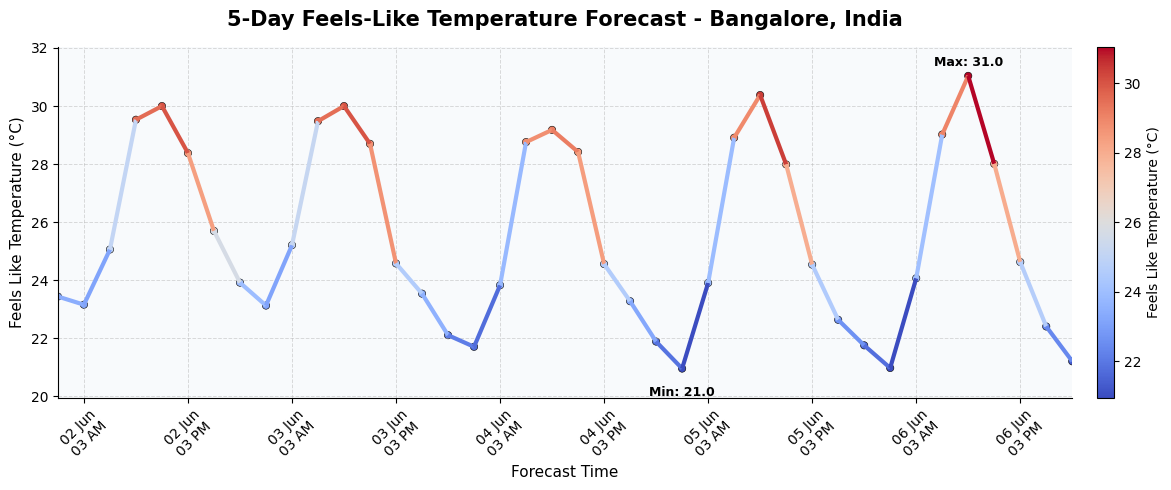

In [38]:
plot_gradient_line(
    df=forecast_df,
    x_col="datetime",
    y_col="feels_like_celsius",
    title=f"5-Day Feels-Like Temperature Forecast - {LOCATION_NAME}",
    ylabel="Feels Like Temperature (°C)",
    save_path="weather_charts/feels_like_forecast.png",
    cmap="coolwarm"
)

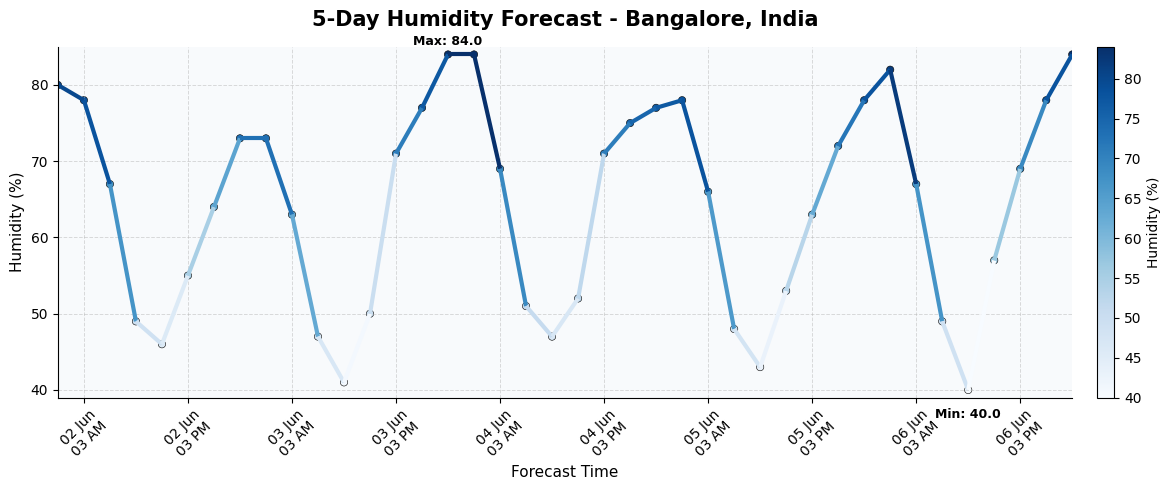

In [39]:
plot_gradient_line(
    df=forecast_df,
    x_col="datetime",
    y_col="humidity_percent",
    title=f"5-Day Humidity Forecast - {LOCATION_NAME}",
    ylabel="Humidity (%)",
    save_path="weather_charts/humidity_forecast.png",
    cmap="Blues"
)

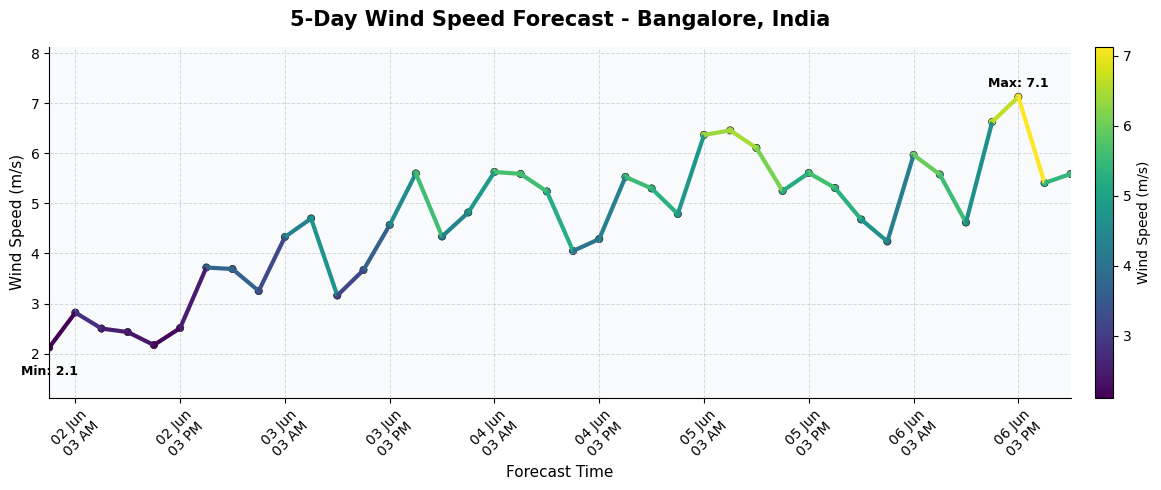

In [40]:
plot_gradient_line(
    df=forecast_df,
    x_col="datetime",
    y_col="wind_speed_mps",
    title=f"5-Day Wind Speed Forecast - {LOCATION_NAME}",
    ylabel="Wind Speed (m/s)",
    save_path="weather_charts/wind_speed_forecast.png",
    cmap="viridis"
)

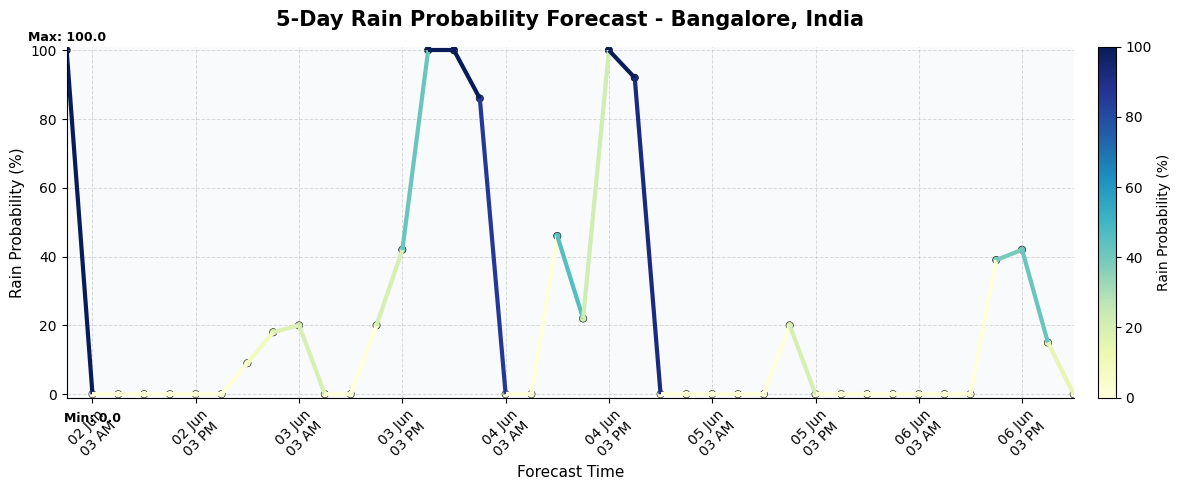

In [41]:
forecast_df["rain_probability_percent"] = forecast_df["pop_probability"] * 100

plot_gradient_line(
    df=forecast_df,
    x_col="datetime",
    y_col="rain_probability_percent",
    title=f"5-Day Rain Probability Forecast - {LOCATION_NAME}",
    ylabel="Rain Probability (%)",
    save_path="weather_charts/rain_probability_forecast.png",
    cmap="YlGnBu"
)

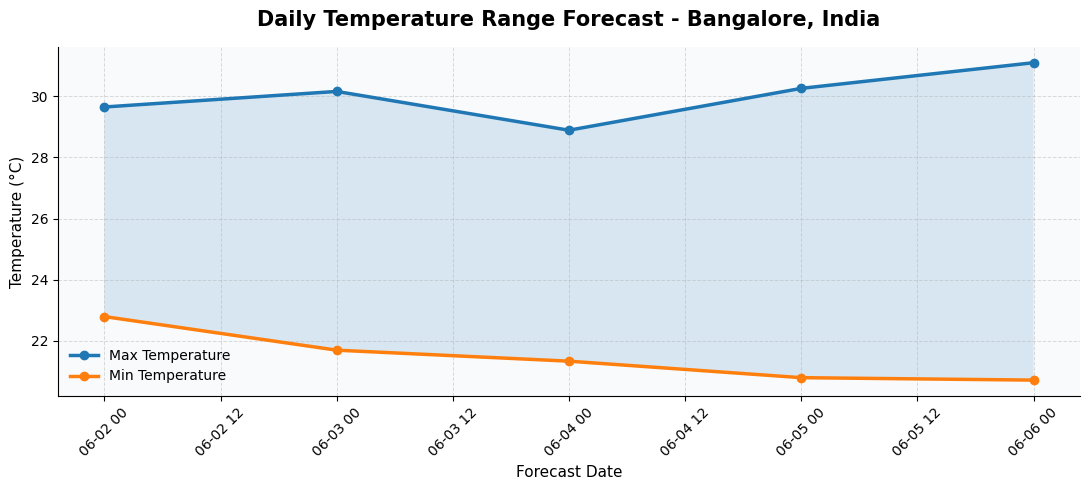

In [42]:
fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("#F8FAFC")

ax.plot(
    daily_summary_df["date"],
    daily_summary_df["temp_max_celsius"],
    marker="o",
    linewidth=2.5,
    label="Max Temperature"
)

ax.plot(
    daily_summary_df["date"],
    daily_summary_df["temp_min_celsius"],
    marker="o",
    linewidth=2.5,
    label="Min Temperature"
)

ax.fill_between(
    daily_summary_df["date"],
    daily_summary_df["temp_min_celsius"],
    daily_summary_df["temp_max_celsius"],
    alpha=0.15
)

apply_chart_style(
    ax=ax,
    title=f"Daily Temperature Range Forecast - {LOCATION_NAME}",
    xlabel="Forecast Date",
    ylabel="Temperature (°C)"
)

ax.legend(frameon=False)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("weather_charts/daily_min_max_temperature.png", dpi=300, bbox_inches="tight")
plt.show()

In [43]:
styled_daily_summary = daily_summary_df.style.background_gradient(
    subset=[
        "temp_min_celsius",
        "temp_max_celsius",
        "temp_avg_celsius",
        "humidity_avg_percent",
        "wind_speed_avg_mps",
        "rain_probability_max",
        "cloudiness_avg_percent"
    ],
    cmap="YlOrRd"
).format({
    "temp_min_celsius": "{:.1f}",
    "temp_max_celsius": "{:.1f}",
    "temp_avg_celsius": "{:.1f}",
    "humidity_avg_percent": "{:.1f}",
    "wind_speed_avg_mps": "{:.1f}",
    "rain_probability_max": "{:.2f}",
    "cloudiness_avg_percent": "{:.1f}"
})

styled_daily_summary

,date,temp_min_celsius,temp_max_celsius,temp_avg_celsius,humidity_avg_percent,wind_speed_avg_mps,rain_probability_max,cloudiness_avg_percent
0,2026-06-02,22.8,29.6,25.7,64.0,2.7,1.00,66.2
1,2026-06-03,21.7,30.2,25.6,63.2,4.2,1.00,79.9
2,2026-06-04,21.3,28.9,24.8,65.8,5.1,1.00,89.4
3,2026-06-05,20.8,30.3,24.9,62.6,5.6,0.20,59.4
4,2026-06-06,20.7,31.1,24.8,65.8,5.6,0.42,81.8


In [44]:
os.listdir("weather_charts")

['wind_speed_forecast.png',
 'humidity_forecast.png',
 'temperature_forecast.png',
 'feels_like_forecast.png',
 'daily_min_max_temperature.png',
 'rain_probability_forecast.png']